In [48]:
import ast
import glob
import warnings
from collections import defaultdict
from datetime import date

import numpy as np
import pandas as pd
import wandb

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import os
import json


today = date.today()
api = wandb.Api()

# # Find all csv files in the current directory
csv_files = glob.glob("csv/*.csv")
# # Collect all the names of the csv files without the extension
csv_names = [csv_file[:-4] for csv_file in csv_files]
project_name = "6g_4rd_September"  
user = "telyatnikov_sap"

if project_name not in csv_names:
    runs = api.runs(f"{user}/{project_name}")

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)

        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k, v in run.config.items() if not k.startswith("_")}
        )

        # .name is the human-readable name of the run.
        name_list.append(run.name)

    runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

    runs_df.to_csv(f"csv/{user}_{project_name}.csv")
else:
    runs_df = pd.read_csv(f"csv/{user}_{project_name}.csv", index_col=0)

    for row in runs_df.iloc:
        row["summary"] = ast.literal_eval(row["summary"])
        row["config"] = ast.literal_eval(row["config"])


for row in runs_df.iloc:
    row["summary"].update(row["config"])

lst = [i["summary"] for i in runs_df.iloc]
df = pd.DataFrame.from_dict(lst)

df_init = df.copy()

# drop row 0
#df = df.drop(df.index[-1])

In [49]:
def normalize_column(df, column_to_normalize):
    # Use json_normalize to flatten the nested dictionaries into separate columns
    flattened_df = pd.json_normalize(df[column_to_normalize])
    # Rename columns to include 'nested_column' prefix
    flattened_df.columns = [
        f"{column_to_normalize}.{col}" for col in flattened_df.columns
    ]
    # Concatenate the flattened DataFrame with the original DataFrame
    result_df = pd.concat([df, flattened_df], axis=1)
    # Get new columns names
    new_columns = flattened_df.columns
    # Drop the original nested column if needed
    result_df.drop(column_to_normalize, axis=1, inplace=True)
    return result_df, new_columns


# Config columns to normalize
columns_to_normalize = ["decoder", 'compressor']
# df.fillna('NA', inplace=True)
# df = df[df['test/loss'] != 'NA']
# Keep track of config columns added
config_columns = []
for column in columns_to_normalize:
    df, columns = normalize_column(df, column)
    config_columns.extend(columns)



# substitute NaN with 'NA'
df.fillna('NA', inplace=True)
df = df[df['Elements compression'] != 'NA']
df = df[df['compressor.name'] != 'NA'] 
df['compressor.r'] = df['compressor.r'].apply(lambda x: str(x))
df['Elements compression'] = df['Elements compression'].apply(lambda x: np.round((1 - x)*100))
# Rename No Compression to VIT

# First rename conditional cases: 
df.loc[(df['compressor.name'] == 'AE') & (df['reconstruct_images'] == False), 'compressor.name'] = 'AC'

# Second rename conditional cases: 
df.loc[(df['compressor.name'] == 'Tome+AE') & (df['reconstruct_images'] == False), 'compressor.name'] = 'TAC'

df.loc[(df['compressor.name'] == 'Tome+AE') & (df['reconstruct_images'] == True), 'compressor.name'] = 'TACR'


rename_dict = {
    'No Compression': 'VIT',
    'Tome':'TCR', 
    'AE':'ACR', 
    'Tome+onlyclassifier':'TC'
}

df['compressor.name'] = df['compressor.name'].apply(lambda x: rename_dict[x] if x in rename_dict else x)

/tmp/ipykernel_1817403/4273060344.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('NA', inplace=True)


In [51]:
df['compressor.name'].unique()

array(['TAC', 'TACR', 'AC', 'ACR', 'TCR', 'TC'], dtype=object)

In [52]:
# TODO
#df[(df['compressor.name'] == 'AE') & (df['reconstruct_images']==False)]






In [53]:
# drop row that have only 'NA'
df = df.dropna()

In [54]:
from collections import defaultdict

results = defaultdict(dict)
#df['model_type'].dropna(inplace=True)
#df[['model_type',  'decoder.use_trace_loss', 'Token compression', 'val/best_accuracy', 'validate_snr_db']]
df['model_type'] = df['model_type'].apply(lambda x: ' '.join(x.split('_')[-2:]))

In [55]:

# df.experiments_dir df.experiment_name
# Go over the rows and create path
new_col = []
for i, row in df.iterrows():
    new_col.append(f"{row['experiments_dir']}{row['experiment_name']}")

df['path'] = new_col

In [56]:
df['path']

0     log/runs/2024-09-07-00-55-47
1     log/runs/2024-09-07-00-28-44
2     log/runs/2024-09-06-23-55-58
3     log/runs/2024-09-06-23-27-30
4     log/runs/2024-09-06-22-54-39
                  ...             
56    log/runs/2024-09-05-01-25-29
57    log/runs/2024-09-05-00-54-15
58    log/runs/2024-09-05-00-28-18
59    log/runs/2024-09-05-00-01-46
60    log/runs/2024-09-04-23-30-16
Name: path, Length: 61, dtype: object

### Main comrapison

/tmp/ipykernel_1817403/3136735567.py:230: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=3)  # Increase space between subplots


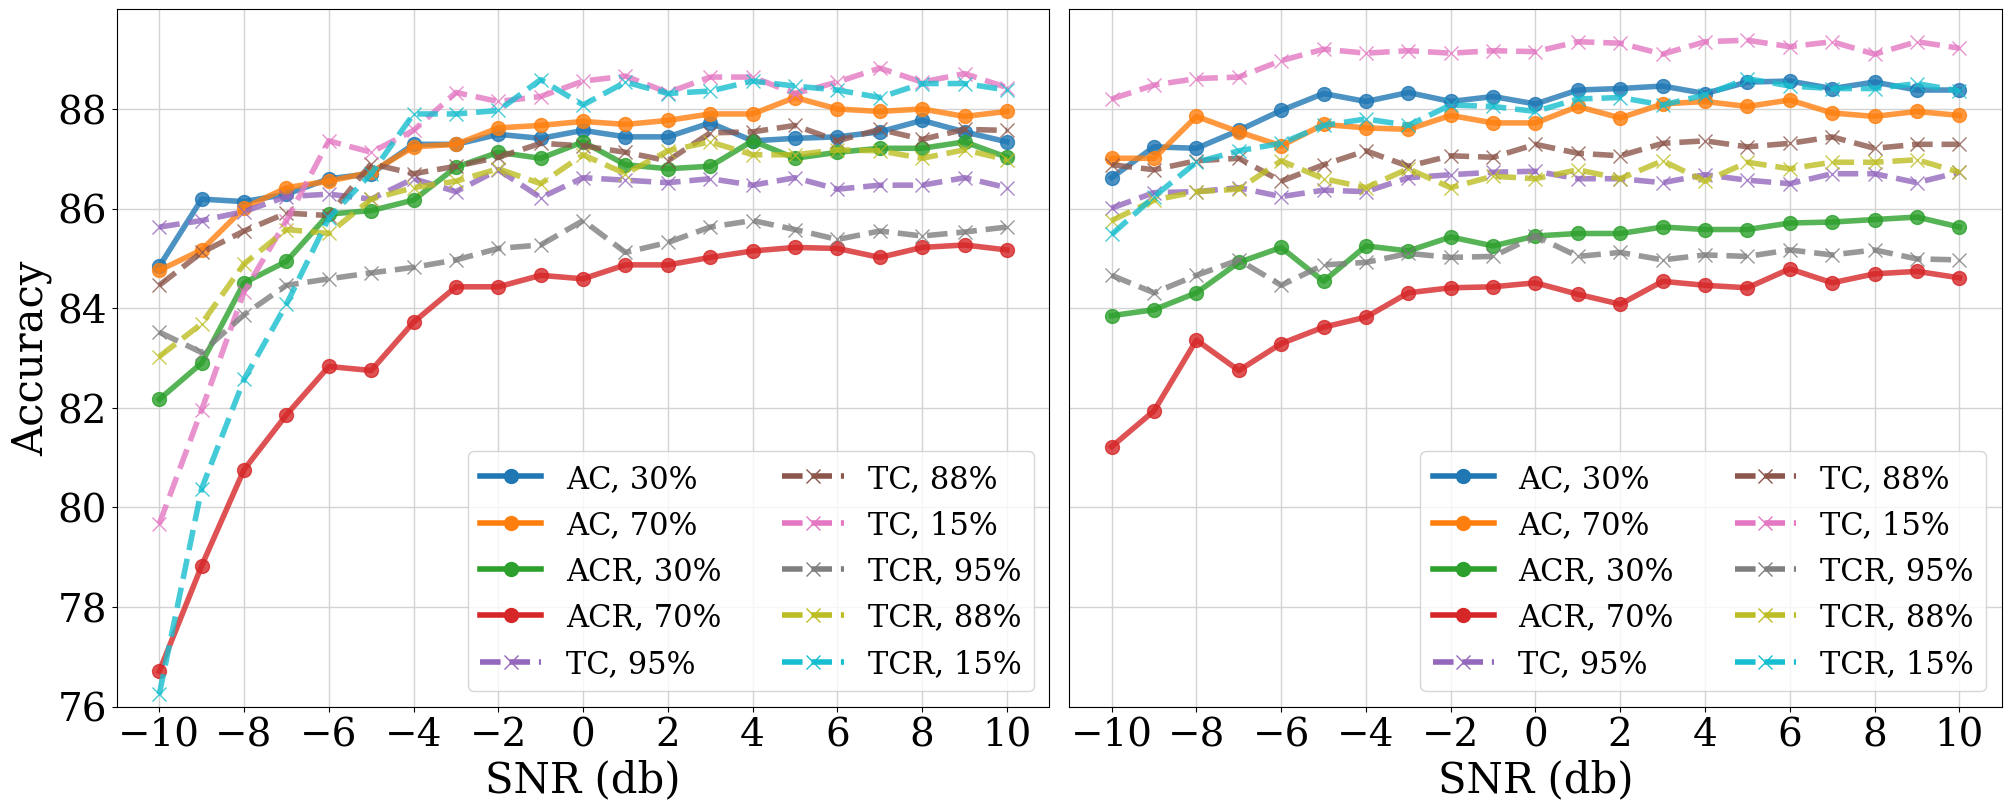

In [81]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    0: {
        'AC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },

        'ACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },

        'TC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
       
        'TCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        }
        },
    1: {

        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },
        
        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },

        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        }
        },
}



# Line styles and markers for each model
# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    "ACR": 'solid', 
   
    "TC": 'dashed', 
    "TCR": 'dashed', 

    "TAC": 'dashdot', 
    "TACR": 'dashdot', 
}

markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',  
}
markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": 'o', 
    "TACR": 'o',  
}

# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 22,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
with plt.rc_context(settings):
    num_plots = 2
    fig, axs = plt.subplots(1, num_plots, figsize=(20, 8))  # Create 3 subplots in a 1x3 grid
    for ax_idx in range(num_plots):
        ax = axs[ax_idx]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=4,
                # make the likes a bit more transparent
                alpha=0.8,
                markersize=10,
            )

            # Create legend elements
            legend_elements = [
                Line2D(
                    [0], [0], 
                    color=color_dict[idx], 
                    lw=4, 
                    linestyle=line_styles[combination['compressor.name']], 
                    marker=markers[combination['compressor.name']],
                    markersize=10, 
                    label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
                ) 
                for idx, combination in unique_combinations_collector.iterrows()
            ]

            # Add legends to the first subplot
            ax.legend(handles=legend_elements, ncol=2, loc='lower right')
        
       
    
    # Set x-ticks to integer values and adjust labels for both subplots
    for idx, ax in enumerate(axs):
        ax.set_ylim(76,  90)
        ax.set_xticks(snr.astype(int)[::2])
        ax.set_xlabel('SNR (db)', fontsize=30)
        ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

        if idx == 0:
            ax.set_ylabel('Accuracy', fontsize=30)
            ax.set_yticks(np.arange(76, 90, 2))
        else:
            ax.set_yticks([])  # Remove y-ticks from the second and third subplots
            ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

            # Add y-axis grid lines manually
            for ytick in np.arange(76,  90, 2):
                ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=3)  # Increase space between subplots
    

# Save and show plot
output_pdf_path = f"images/performance_plot_{today}.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()


/tmp/ipykernel_1817403/1951509825.py:245: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=3)  # Increase space between subplots


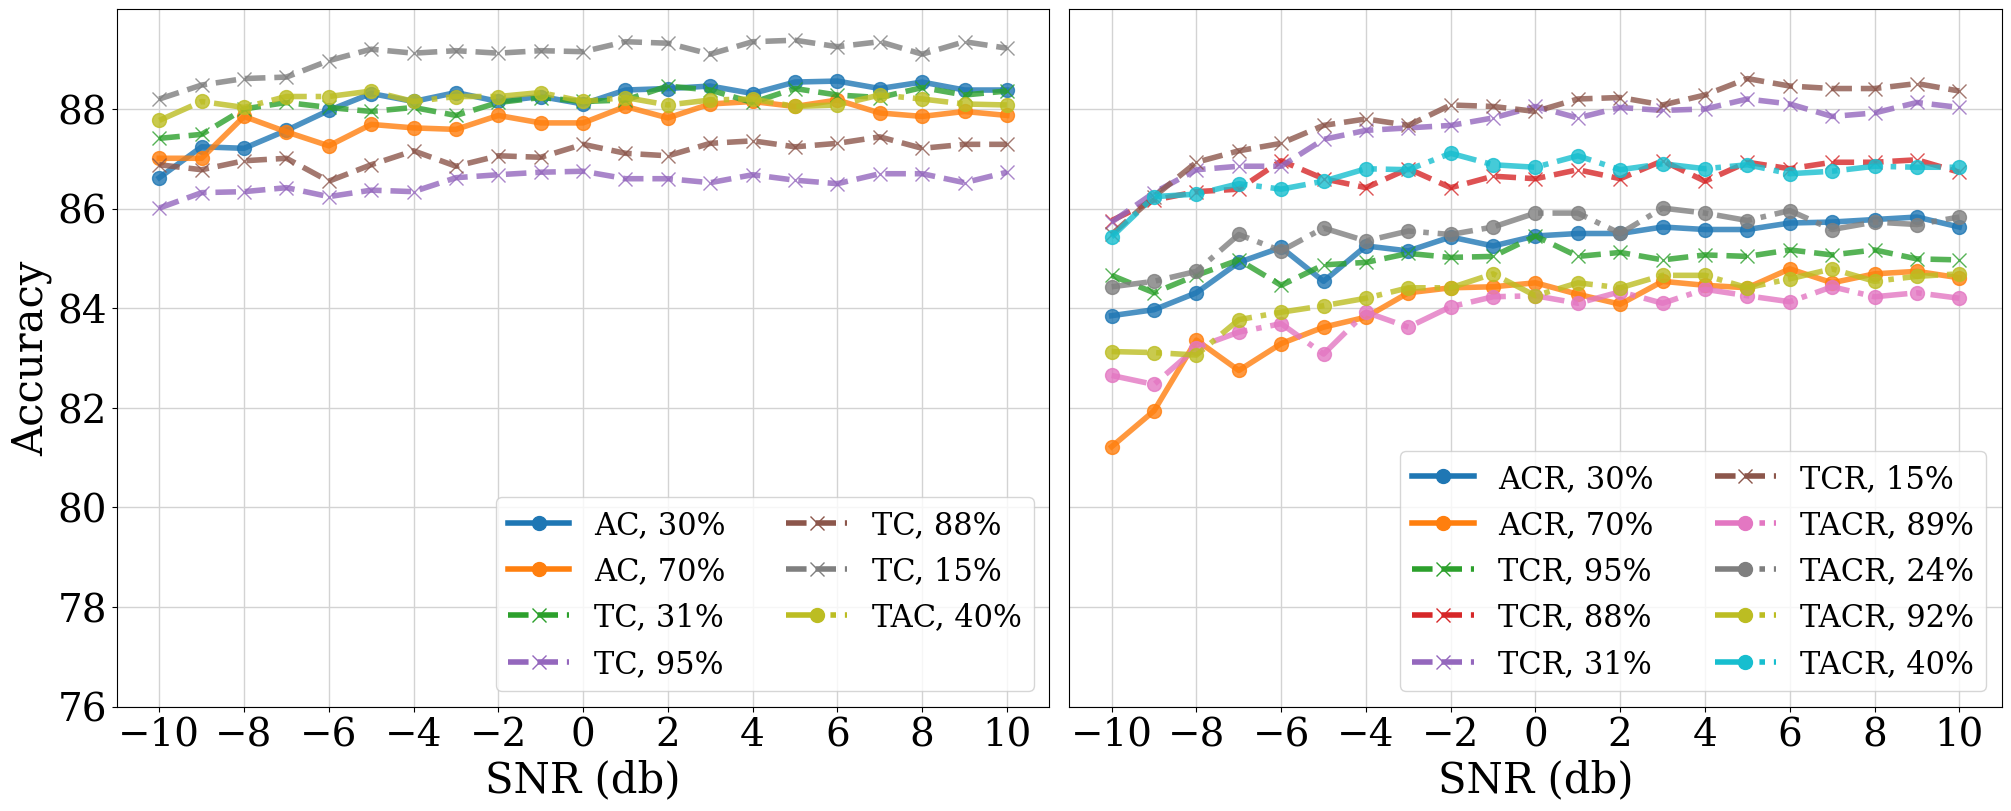

In [98]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    0: {
        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           'Elements compression': [70, 30]
        },

        # 'ACR': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #    'Elements compression': [70, 30]
        # },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 31., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },

        'TAC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
       #     'Elements compression': [ 15., 31., 88., 95.], 
            #'compressor.use_trace_loss': [True]
        },
       
        # 'TCR': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [15., 88., 95.], 
        #     'compressor.use_trace_loss': [True],
        
        # }
        },
    1: {

        # 'AC': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [70, 30],
        # },
        
        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },

        # 'TC': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [15., 88., 95.], 
        #     #'compressor.use_trace_loss': [True]
        # },

        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 31., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        },

        'TACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
           # 'Elements compression': [ 15., 31., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        }
        },
}



# Line styles and markers for each model
# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    "ACR": 'solid', 
   
    "TC": 'dashed', 
    "TCR": 'dashed', 

    "TAC": 'dashdot', 
    "TACR": 'dashdot', 
}

markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',  
}
markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": 'o', 
    "TACR": 'o',  
}

# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 22,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
with plt.rc_context(settings):
    num_plots = 2
    fig, axs = plt.subplots(1, num_plots, figsize=(20, 8))  # Create 3 subplots in a 1x3 grid
    for ax_idx in range(num_plots):
        ax = axs[ax_idx]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=4,
                # make the likes a bit more transparent
                alpha=0.8,
                markersize=10,
            )

            # Create legend elements
            legend_elements = [
                Line2D(
                    [0], [0], 
                    color=color_dict[idx], 
                    lw=4, 
                    linestyle=line_styles[combination['compressor.name']], 
                    marker=markers[combination['compressor.name']],
                    markersize=10, 
                    label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
                ) 
                for idx, combination in unique_combinations_collector.iterrows()
            ]

            # Add legends to the first subplot
            ax.legend(handles=legend_elements, ncol=2, loc='lower right')
        
       
    
    # Set x-ticks to integer values and adjust labels for both subplots
    for idx, ax in enumerate(axs):
        ax.set_ylim(76,  90)
        ax.set_xticks(snr.astype(int)[::2])
        ax.set_xlabel('SNR (db)', fontsize=30)
        ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

        if idx == 0:
            ax.set_ylabel('Accuracy', fontsize=30)
            ax.set_yticks(np.arange(76, 90, 2))
        else:
            ax.set_yticks([])  # Remove y-ticks from the second and third subplots
            ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

            # Add y-axis grid lines manually
            for ytick in np.arange(76,  90, 2):
                ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=3)  # Increase space between subplots
    

# Save and show plot
output_pdf_path = f"images/performance_plot_{today}.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()

In [88]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
27,135,ACR,False,random,30.0,NaN,NaN
42,58,ACR,False,random,70.0,NaN,NaN
24,192,TCR,False,random,95.0,True,"[40, 40, 40, 40, 40, 40]"
26,192,TCR,False,random,88.0,True,"[30, 30, 30, 30, 30, 30]"
29,192,TCR,False,random,31.0,True,"[10, 10, 10, 10, 10, 10]"
31,192,TCR,False,random,15.0,True,"[5, 5, 5, 5, 5, 5]"


In [102]:
df[(df['compressor.name'] =='TAC')&(df['train_snr_db'] == 'random')]['compressor.encoding_dim']

0    135
Name: compressor.encoding_dim, dtype: int64

/tmp/ipykernel_1817403/4170799144.py:209: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.3)  # Increase space between subplots


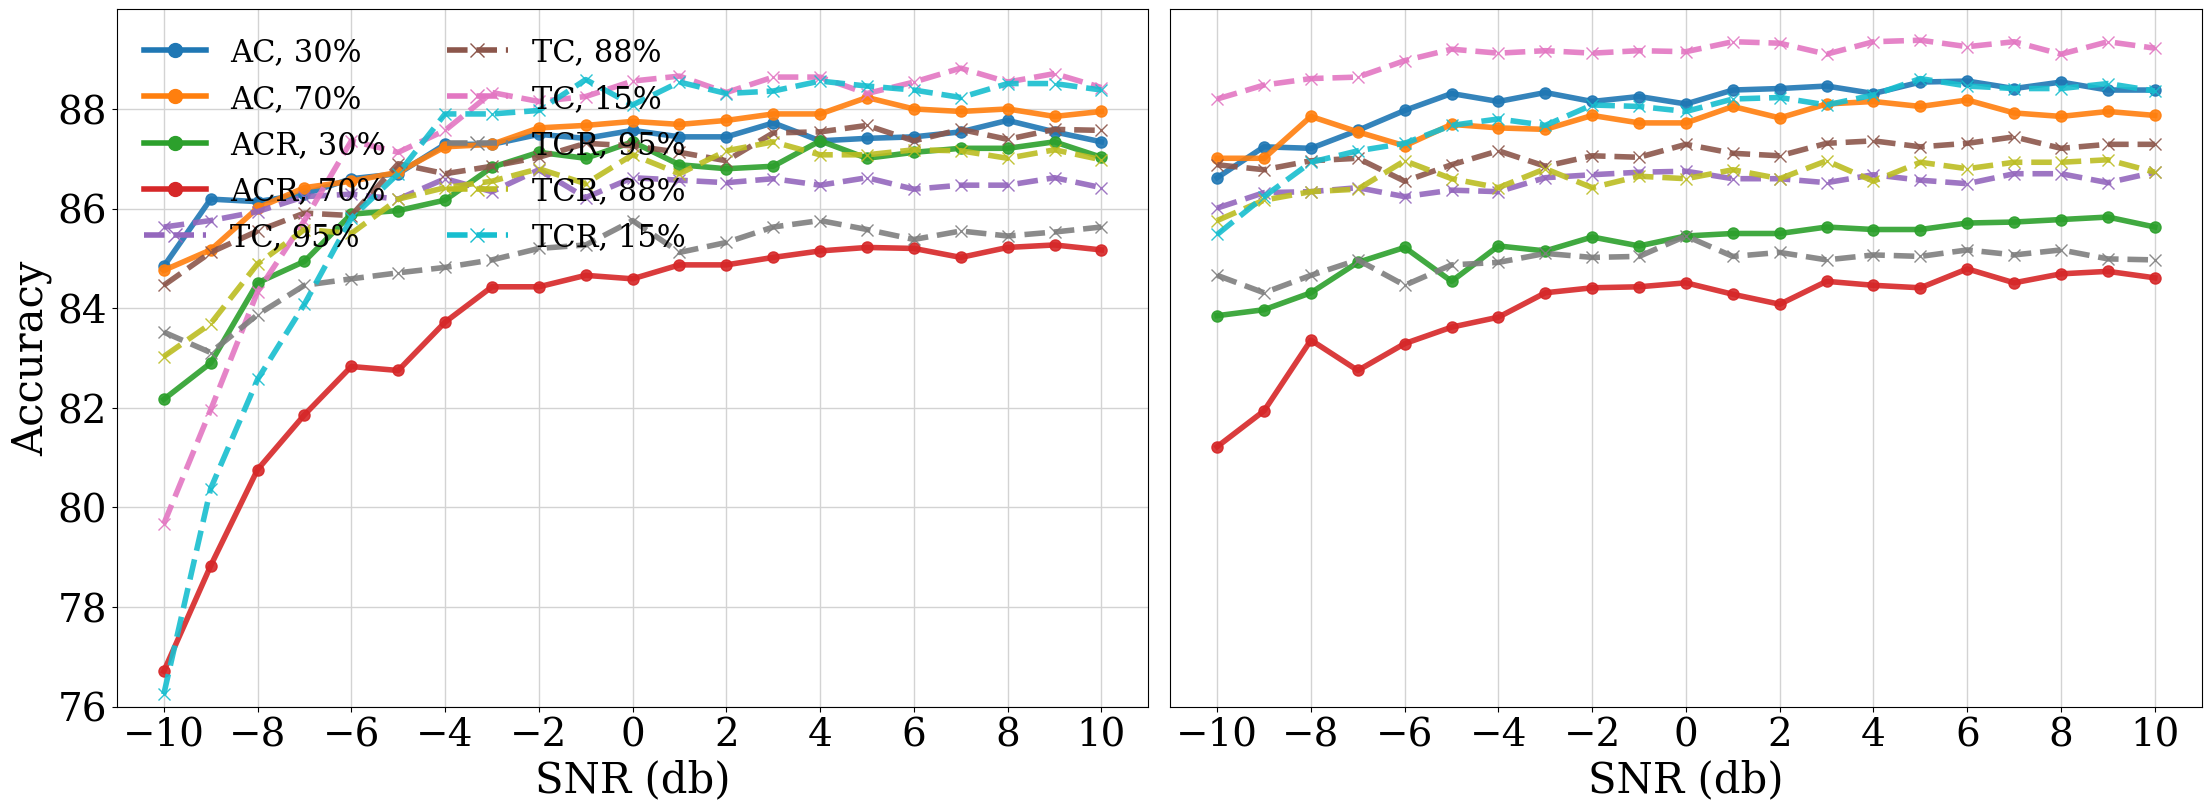

In [80]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACR':['compressor.encoding_dim'] + shared_sweep_columns,
    'AC':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TC': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,
    'TCR': ['compressor.use_trace_loss', 'compressor.r', 'compressor.encoding_dim'] + shared_sweep_columns,

    'TAC': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
    'TACR': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,

    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    0: {
        'AC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30]
        },

        'ACR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30]
        },

        'TC': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
        },
       
        'TCR': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        }
        },
    1: {

        'AC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },
        
        'ACR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 30],
        },

        'TC': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 88., 95.], 
        },

        'TCR': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15., 88., 95.], 
            'compressor.use_trace_loss': [True],
        
        }
        },
}



# Line styles and markers for each model
line_styles = {
    'AC': 'solid',
    "ACR": 'solid', 
   
    "TC": 'dashed', 
    "TCR": 'dashed', 

    "TAC": 'dashdot', 
    "TACR": 'dashdot', 
}
markers = {
    "AC": 'o',
    "ACR": 'o',
    
    "TC": 'x', 
    "TCR": 'x', 

    "TAC": '^', 
    "TACR": '^',  
}

# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 20,
    'axes.labelsize': 35,
    'legend.fontsize': 22,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 40
}
df_copy = df.copy()
with plt.rc_context(settings):
    num_plots = 2
    fig, axs = plt.subplots(1, num_plots, figsize=(22, 8))  # Create 2 subplots in a 1x2 grid
    for ax_idx in range(num_plots):
        ax = axs[ax_idx]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
        
        
        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=4,
                alpha=0.9,  # Slightly increase transparency for clarity
                markersize=8,
            )

        # Create legend elements
        legend_elements = [
            Line2D(
                [0], [0], 
                color=color_dict[idx], 
                lw=4, 
                linestyle=line_styles[combination['compressor.name']], 
                marker=markers[combination['compressor.name']],
                markersize=10, 
                label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
            ) 
            for idx, combination in unique_combinations_collector.iterrows()
        ]

        # Add legends to the first subplot
        if ax_idx == 0:
            ax.legend(handles=legend_elements, ncol=2, loc='upper left', frameon=False)  # Change legend location
        
        ax.set_ylim(76, 90)
        ax.set_xticks(snr.astype(int)[::2])
        ax.set_xlabel('SNR (db)', fontsize=30)
        ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

        if ax_idx == 0:
            ax.set_ylabel('Accuracy', fontsize=30)
            ax.set_yticks(np.arange(76, 90, 2))
        else:
            ax.set_yticks([])  # Remove y-ticks from the second plot
            ax.grid(True, axis='y', linestyle='--', alpha=0.5)  # Lighter grid lines

    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.3)  # Increase space between subplots
    

# Save and show plot
output_pdf_path = f"images/performance_plot_{today}.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()


In [74]:
unique_combinations_collector#.drop_duplicates()

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
14,135,AC,False,0,30.0,NA,NA
16,58,AC,False,0,70.0,NA,NA
28,135,ACR,False,0,30.0,NA,NA
44,58,ACR,False,0,70.0,NA,NA
41,192,TCR,False,0,95.0,True,"[40, 40, 40, 40, 40, 40]"
43,192,TCR,False,0,88.0,True,"[30, 30, 30, 30, 30, 30]"
46,192,TCR,False,0,15.0,True,"[5, 5, 5, 5, 5, 5]"
48,192,TCR,False,0,95.0,False,"[40, 40, 40, 40, 40, 40]"
50,192,TCR,False,0,88.0,False,"[30, 30, 30, 30, 30, 30]"
52,192,TCR,False,0,15.0,False,"[5, 5, 5, 5, 5, 5]"


In [65]:
selected_idx[0]

0     False
1     False
2     False
3     False
4     False
      ...  
56    False
57    False
58    False
59    False
60    False
Name: compressor.encoding_dim, Length: 61, dtype: bool

In [66]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
11,135.0,ACRVIT,False,0,30.0,NA,NA
27,58.0,ACRVIT,False,0,70.0,NA,NA
37,NA,TCVIT,False,0,0.0,False,"[0, 0, 0, 0, 0, 0]"
41,NA,TCVIT,False,0,95.0,False,"[40, 40, 40, 40, 40, 40]"
42,NA,TCVIT,False,0,88.0,False,"[30, 30, 30, 30, 30, 30]"
43,NA,TCVIT,False,0,15.0,False,"[5, 5, 5, 5, 5, 5]"
24,NA,TCRVIT,False,0,95.0,True,"[40, 40, 40, 40, 40, 40]"
26,NA,TCRVIT,False,0,88.0,True,"[30, 30, 30, 30, 30, 30]"
29,NA,TCRVIT,False,0,15.0,True,"[5, 5, 5, 5, 5, 5]"


30    TCVIT
32    TCVIT
36    TCVIT
37    TCVIT
38    TCVIT
39    TCVIT
40    TCVIT
41    TCVIT
42    TCVIT
43    TCVIT
Name: compressor.name, dtype: object

In [149]:
df[df['compressor.name'] == 'TCRVIT']['compressor.r']

1    [10, 10, 10, 10, 10, 10]
2          [5, 5, 5, 5, 5, 5]
Name: compressor.r, dtype: object

In [ ]:
mask

array([False, False, False, False, False])

In [ ]:
subset['path']

Series([], Name: path, dtype: object)

In [ ]:
snr

NameError: name 'snr' is not defined

In [ ]:
results

defaultdict(dict, {})

In [ ]:
unique_combinations_collector

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r


### Table 

In [34]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'ACRVIT': ['compressor.encoding_dim'] + shared_sweep_columns,
    'TVIT': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
    'PCAVIT': ['compressor.q'] + shared_sweep_columns,
    'VIT': shared_sweep_columns
}

# Filter conditions for each model
filter_conditions = {
    0: {
       
        'TVIT': {
            'train_snr_db': [0, 'random'], 
            'train_classifier_separetely': [False], 
            #'Elements compression': [15., 31.,66., 88., 95.], 
            'compressor.use_trace_loss': [True, False]
        },
       
        },
    1: {
        'ACRVIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [70, 40, 10]
        },
        'TVIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [15., 31., 88., 95.], 
            'compressor.use_trace_loss': [True]
        },
        'VIT': {
            'train_snr_db': ['random'], 
            'train_classifier_separetely': [False], 
            'Elements compression': [0]
        }},
    2: {
        # 'ACRVIT': {
        #     'train_snr_db': [0], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [70, 40, 10]
        # },
        'TVIT': {
            'train_snr_db': ['random', 0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15,  88.],  # 88., 95.
            'compressor.use_trace_loss': [True, False]
        },
        
        'VIT': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [0]
        }},
}


df_copy = df.copy()

num_plots = 1

for ax_idx in range(num_plots):
    ax = axs[ax_idx]

    unique_combinations_collector = pd.DataFrame()
    ax_fc = filter_conditions[ax_idx]
    for compressor_name in ax_fc.keys():
        compressor_df = df.loc[df['compressor.name'] == compressor_name]
        sweep_columns = personalised_sweep_columns[compressor_name]
        unique_combinations = compressor_df[sweep_columns].drop_duplicates()

        # Filter according to conditions
        for condition, values in ax_fc[compressor_name].items():
            unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

        unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])
    
    # def update_name(row):
    #     if row['compressor.use_trace_loss']==False and row['compressor.name'] == 'TVIT':
    #         return 'No Trace Loss'
    #     return 'Trace Loss'
    # Apply the function to the DataFrame
    #unique_combinations_collector['compressor.name'] = unique_combinations_collector.apply(update_name, axis=1)
    #df_copy['compressor.name'] = df_copy.apply(update_name, axis=1)

    # Assign unique colors for each combination
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
    color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

    unique_combinations_collector.fillna('NA', inplace=True)

    unique_combinations_collector[unique_combinations_collector['compressor.name'].isin(['TVIT'])]


snr_vals_to_keep = [-10, 0, 10]
new_df = []
for idx, combination in unique_combinations_collector.iterrows():
    selected_idx = [df_copy[key] == val for key, val in combination.items()]
    mask = np.logical_and.reduce(selected_idx)
    subset = df_copy[mask]
    path_to_json = os.path.join(subset['path'].item(), 'results.json')

    # Load and plot results
    with open(path_to_json, 'r') as f:
        results = json.load(f)

    snr = np.array(list(results.keys())).astype(float)
    accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)

   
    new_df.append({
                'snr': 'Average', 
                'accuracy_mean': np.round(accuracy.mean(),2),
                'accuracy_std': np.round(accuracy.std(),2), #f'{accuracy.mean()} ± {accuracy.std()}', 
                'compressor.name': combination['compressor.name'], 
                'compressor.use_trace_loss': combination['compressor.use_trace_loss'],
                'Elements compression': combination['Elements compression'],  # Add a comma here
                'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'NoNoise',
            })
    
    # for s,acc in zip(snr, accuracy):
        # if s in snr_vals_to_keep:
        #     new_df.append({
        #         'snr': s, 
        #         'accuracy': acc, 
        #         'compressor.name': combination['compressor.name'], 
        #         'compressor.use_trace_loss': combination['compressor.use_trace_loss'],
        #         'Elements compression': combination['Elements compression'],  # Add a comma here
        #         'train_snr_db': 'Noise' if combination['train_snr_db']=='random' else 'NoNoise',
        #     })

new_df = pd.DataFrame(new_df)
#new_df['accuracy'] = new_df['accuracy_mean'].astype(str) + ' ± ' + new_df['accuracy_std'].astype(str)

#Create a pivot table and consider to have accuracy_mean +- accuracy_std
pivot_df_mean = new_df.pivot_table(
    index=['Elements compression'], 
    columns=['train_snr_db', 'compressor.use_trace_loss'], 
    values='accuracy_mean'
)

pivot_df_std = new_df.pivot_table(
    index=['Elements compression', 'snr'], 
    columns=['train_snr_db', 'compressor.name'], 
    values='accuracy_std'
)




# # Create a pivot table
# pivot_df = new_df.pivot_table(
#     index=['Elements compression', 'snr'], 
#     columns=['train_snr_db', 'compressor.name'], 
#     values='accuracy'
# )



KeyError: 'accuracy_mean'

,compressor.encoding_dim,compressor.name,train_classifier_separetely,train_snr_db,Elements compression,compressor.use_trace_loss,compressor.r
0,192.0,AEVIT,False,random,0.0,NA,NA
1,192.0,AEVIT,False,0,0.0,NA,NA
2,173.0,AEVIT,False,random,10.0,NA,NA
4,173.0,AEVIT,False,0,10.0,NA,NA
6,154.0,AEVIT,False,random,20.0,NA,NA
8,154.0,AEVIT,False,0,20.0,NA,NA
10,135.0,AEVIT,False,random,30.0,NA,NA
11,135.0,AEVIT,False,0,30.0,NA,NA
13,116.0,AEVIT,False,random,40.0,NA,NA
15,116.0,AEVIT,False,0,40.0,NA,NA


In [33]:
selected_idx[0]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
Name: compressor.encoding_dim, dtype: bool

In [ ]:
df['experiments_dir']


0    log/runs/
1    log/runs/
2    log/runs/
3    log/runs/
4    log/runs/
5    log/runs/
6    log/runs/
Name: experiments_dir, dtype: object

In [ ]:
# Data frame from list of dictionaries
